In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.data_loader import data_loader
from src.mel_filterbank import mel_filterbank
from src.get_MFBM import get_MFBM
from src.export_dataframe import export_dataframe


All signals have the same sampling rate: 22050 Hz


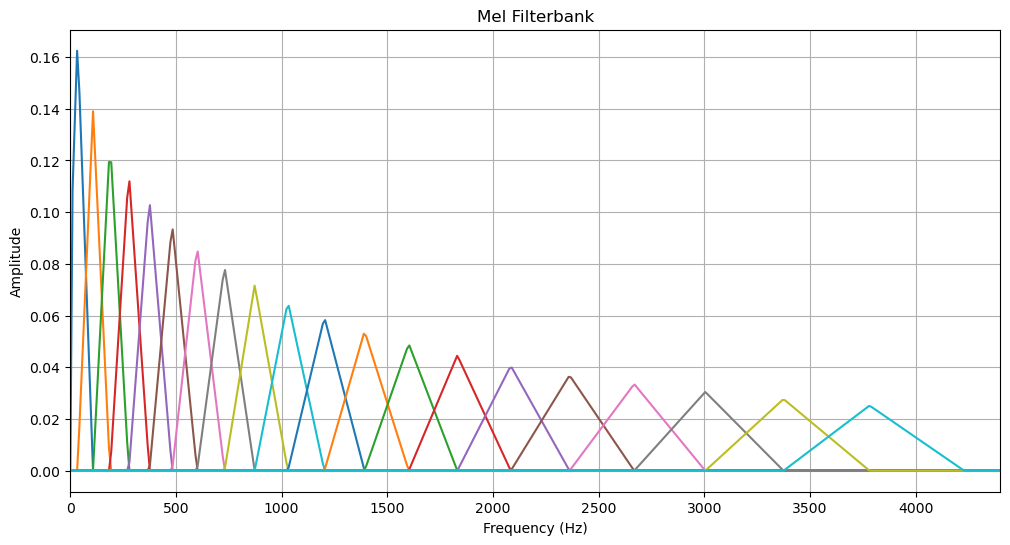

In [2]:
# --- Load data
# No pre-processing done, except Amplitude Normalization
# USP corpus, with 4 classes: Control, Edema, Nodules and Neuro
df, fs = data_loader(dataset_name='myUSP')

# --- Visualization
#df.columns

# --- Parameters
n_fft = 2048
fmax = 4000
mel_bands = 20
sobrep = 0.5     # filter overlap


"""
NOTE: The filter bank shown in the paper (Figure 1) incorrectly depicts 20% overlap.
The actual filter bank used in the original work — and reproduced here — uses 50% overlap,
which is consistent with the results reported in the paper.
"""

# --- Filterbank
mel_filters = mel_filterbank(
    fs, 
    mel_bands, 
    fmax, 
    sobrep, 
    n_fft, 
    print_filters=True, 
    save_path="../results/figures/01mel_filterbank.png")



In [3]:
# --- Parameters
milisegundo = round(fs/1000)
tamanho = 30*milisegundo    # window
passo = 10*milisegundo      # step


# --- MEl Filterbank Magnitudes
mfbm_list = []

for sinal in df['signal']:
    mfbm = get_MFBM(sinal, fs, tamanho, passo, 2048, mel_filters)
    mfbm_list.append(mfbm)

df['MFBM'] = mfbm_list


In [4]:
df2 = export_dataframe(
    df,
    dataset_name="myUSP",
    drop_columns=['signal', 'MFBM', 'path', 'fs']
)

print(df2.columns)

Saved to: ..\data\processed\myUSP.parquet
Index(['file', 'age', 'gender', 'group', 'class', 'MFBM_0', 'MFBM_1', 'MFBM_2',
       'MFBM_3', 'MFBM_4', 'MFBM_5', 'MFBM_6', 'MFBM_7', 'MFBM_8', 'MFBM_9',
       'MFBM_10', 'MFBM_11', 'MFBM_12', 'MFBM_13', 'MFBM_14', 'MFBM_15',
       'MFBM_16', 'MFBM_17', 'MFBM_18', 'MFBM_19'],
      dtype='object')
